<h1>Outliers</h1>

An outlier is a data point that is abnormally distant from all other observations in your dataset. It is an anomaly that does not fit in pattern

<h3>Types of outliers</h3>

- Global Outliers: A point far outside the range of entire dataset (age:150,-30,salary:-345242)
- Contextual Outliers: A point that is an anomaly in a specific context, but normal otherwise(eg. 38C Temperature is normal summer, but abnormal winter).
- Collective Outliers: A subset of data points that deviate together as group (eg. sudden string of 0 sales for 5 days due to website crash)

In [1]:
import pandas as pd
import numpy as np

In [4]:
ages = np.random.normal(loc=25,scale=5,size=200)

outliers = np.array([120,150,-10])

data = np.concatenate([ages,outliers])

df = pd.DataFrame({"Ages":data})

In [6]:
df.tail(10)

,Ages
193,10.015036
194,34.340813
195,18.933264
196,26.457716
197,28.651429
198,24.422093
199,19.174432
200,120.000000
201,150.000000
202,-10.000000


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

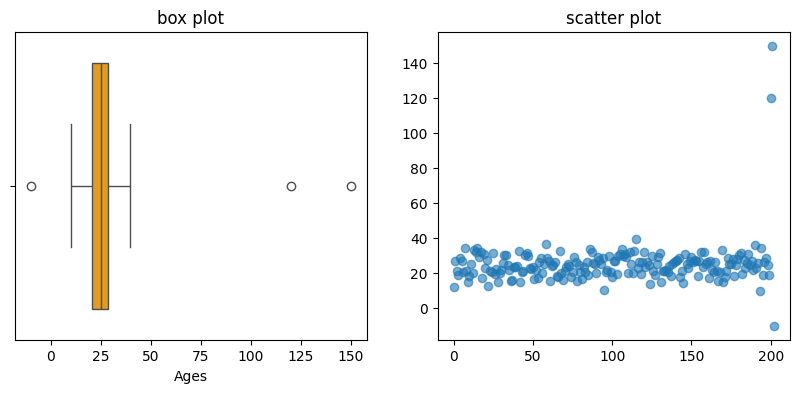

In [8]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.boxplot(x=df['Ages'],color='orange')
plt.title("box plot")

plt.subplot(1,2,2)
plt.scatter(range(len(df)),df['Ages'],alpha=0.6)
plt.title("scatter plot")

plt.show()

<h3>Detect outliers using IQR(Inter quartile range)</h3>

IQR = Q3 - Q1

lower bound = Q1 - 1.5 * IQR

upper bound = Q3 + 1.5 * IQR

In [9]:
Q1 = df['Ages'].quantile(0.25)
Q3 = df['Ages'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR

upper_bound = Q3 + 1.5 * IQR

In [10]:
print(lower_bound, upper_bound)

8.642449764716414 40.644774891417285


In [ ]:
df['Age_'] = np.where(
    df['Ages']>upper_bound,
    upper_bound,
    np.where(
        df['Ages']<lower_bound,
        lower_bound,df['Ages']
        )
    )

In [12]:
df.tail(10)

,Ages,Age_
193,10.015036,10.015036
194,34.340813,34.340813
195,18.933264,18.933264
196,26.457716,26.457716
197,28.651429,28.651429
198,24.422093,24.422093
199,19.174432,19.174432
200,120.000000,40.644775
201,150.000000,40.644775
202,-10.000000,8.642450


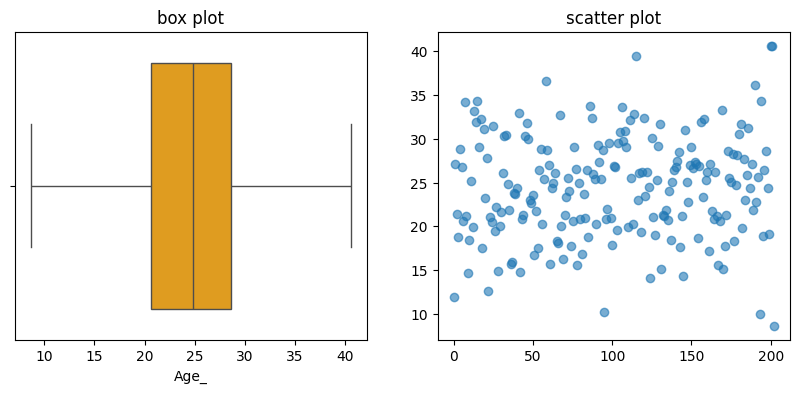

In [13]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.boxplot(x=df['Age_'],color='orange')
plt.title("box plot")

plt.subplot(1,2,2)
plt.scatter(range(len(df)),df['Age_'],alpha=0.6)
plt.title("scatter plot")

plt.show()

<h3>Z-Score</h3>

use the z-score with symmetric data.

In [15]:
np.random.seed(42)

x = np.random.normal(loc=120,scale=10,size=200)

outliers= np.array([190,50,250])

data = np.concatenate([x,outliers])

df = pd.DataFrame({"X":data})

In [16]:
df.tail(10)

,X
193,107.542612
194,121.731809
195,123.853174
196,111.161426
197,121.537251
198,120.582087
199,108.570297
200,190.000000
201,50.000000
202,250.000000


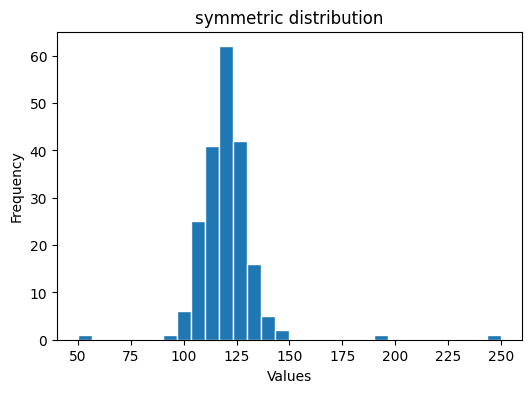

In [18]:
plt.figure(figsize=(6,4))
plt.hist(df['X'],bins=30,edgecolor='w')
plt.title("symmetric distribution")
plt.xlabel("Values")
plt.ylabel("Frequency")
plt.show()

In [19]:
from scipy.stats import zscore

In [20]:
df['z-score'] = zscore(df['X'])

In [21]:
df.tail(10)

,X,z-score
193,107.542612,-0.862657
194,121.731809,0.101451
195,123.853174,0.245591
196,111.161426,-0.616771
197,121.537251,0.088232
198,120.582087,0.023331
199,108.570297,-0.792829
200,190.000000,4.740045
201,50.000000,-4.772484
202,250.000000,8.816843


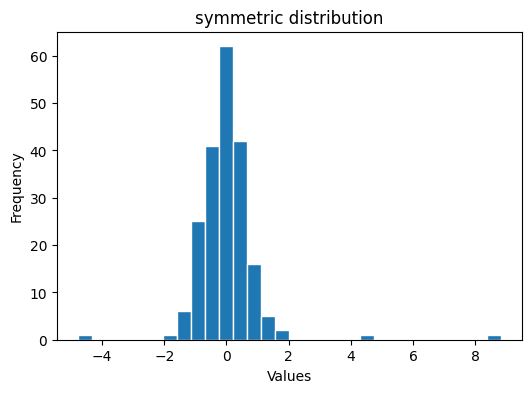

In [22]:
plt.figure(figsize=(6,4))
plt.hist(df['z-score'],bins=30,edgecolor='w')
plt.title("symmetric distribution")
plt.xlabel("Values")
plt.ylabel("Frequency")
plt.show()

Use thresh value , that should be 3 or -3

In [23]:
thres = 3

In [24]:
outliers = df[(df['z-score']>thres) | (df['z-score']<-thres)]

In [25]:
outliers

,X,z-score
200,190.0,4.740045
201,50.0,-4.772484
202,250.0,8.816843
